# Data Speaks!! — Exploratory Data Analysis (EDA)

This notebook performs a comprehensive Exploratory Data Analysis on the IMDB movie review dataset. We will explore the raw dataset, identify messy artifacts, clean the text, and then visualize the true distribution of words and sentiment.

---
## 1. Setup & Imports

In [18]:
import os
import re
import html
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

# Set style for plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.size': 12})

print("Libraries loaded successfully!")

Libraries loaded successfully!


---
## 2. Load the Raw Dataset

In [19]:
DATA_PATH = os.path.join("..", "processed", "imdb_train.csv")

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}\n")
display(df.head())

Dataset shape: (25000, 2)



,text,label
0,In Panic In The Streets Richard Widmark plays ...,1
1,If you ask me the first one was really better ...,0
2,I am a big fan a Faerie Tale Theatre and I've ...,1
3,I just finished reading a book about Dillinger...,0
4,Greg Davis and Bryan Daly take some crazed sta...,0


---
## 3. Basic Data Audit (Missing Values & Duplicates)

In [20]:
print(" Missing Values ")
print(df.isnull().sum())

print("\n Exact Duplicates ")
duplicates = df.duplicated(subset=['text']).sum()
print(f"Total duplicated rows: {duplicates} ({(duplicates/len(df))*100:.2f}% of data)")

print("\nDataset Information:")
df.info()

 Missing Values 
text     0
label    0
dtype: int64

 Exact Duplicates 
Total duplicated rows: 96 (0.38% of data)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    25000 non-null  str  
 1   label   25000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 32.0 MB


---
## 4. Class Distribution Analysis
Checking if the dataset is balanced (equal number of positive and negative reviews).

C:\Users\dhanu\AppData\Local\Temp\ipykernel_600580\2199041134.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', ax=axes[0], palette=['#e74c3c', '#2ecc71'])
C:\Users\dhanu\AppData\Local\Temp\ipykernel_600580\2199041134.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(labels)


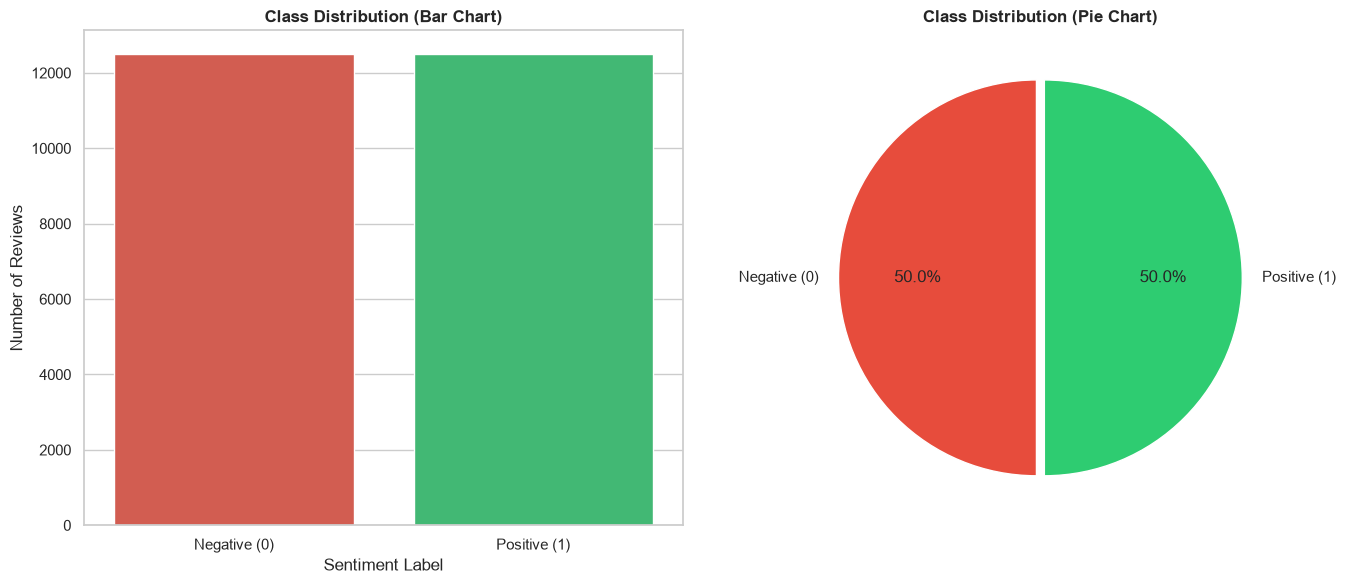

In [21]:
class_counts = df['label'].value_counts()
labels = ['Negative (0)', 'Positive (1)']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar Chart
sns.countplot(data=df, x='label', ax=axes[0], palette=['#e74c3c', '#2ecc71'])
axes[0].set_title('Class Distribution (Bar Chart)', fontweight='bold')
axes[0].set_xticklabels(labels)
axes[0].set_xlabel('Sentiment Label')
axes[0].set_ylabel('Number of Reviews')

# Pie Chart
axes[1].pie(class_counts, labels=labels, autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90, explode=[0.02, 0.02])
axes[1].set_title('Class Distribution (Pie Chart)', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 5. Identifying Messy Artifacts (Raw Data)
Because IMDB reviews are scraped from a website, they contain raw HTML tags (like `<br />`) which will ruin our word analysis if left uncleaned.

In [22]:
html_count = df['text'].str.contains('<br', regex=False, case=False).sum()
print(f"Rows containing '<br' artifact: {html_count} ({(html_count/len(df))*100:.1f}%)")

print("\nExample of a messy review:")
messy_review = df[df['text'].str.contains('<br', regex=False, case=False)]['text'].iloc[0]
print(messy_review[:500] + "...")

Rows containing '<br' artifact: 14665 (58.7%)

Example of a messy review:
In Panic In The Streets Richard Widmark plays U.S. Navy doctor who has his week rudely interrupted with a corpse that contains plague. As cop Paul Douglas properly points out the guy died from two bullets in the chest. That's not the issue here, the two of them become unwilling partners in an effort to find the killers and anyone else exposed to the disease.<br /><br />As was pointed out by any number of people, for some reason director Elia Kazan did not bother to cast the small parts with anyo...


---
## 6. Text Cleaning Preprocessing
We will strip out all HTML tags, decode entities, and normalize whitespace before building WordClouds.

In [23]:
def clean_text(text: str) -> str:
    """Strip HTML tags/entities, normalize whitespace."""
    text = html.unescape(text)                                   # decode &amp; etc.
    text = re.sub(r"<br\s*/?>", " ", text, flags=re.IGNORECASE) # <br /> → space
    text = re.sub(r"<[^>]+>", " ", text)                        # any remaining tags
    text = re.sub(r"\s+", " ", text).strip()                    # collapse whitespace
    return text

# Apply cleaning to a new column
df["text_clean"] = df["text"].apply(clean_text)
print("Text cleaning complete. New column 'text_clean' created.")

# Verify cleaning worked
clean_html_count = df['text_clean'].str.contains('<br', regex=False, case=False).sum()
print(f"Rows containing '<br' in text_clean: {clean_html_count}")

Text cleaning complete. New column 'text_clean' created.
Rows containing '<br' in text_clean: 0


---
## 7. Text Length Analysis (Cleaned Text)
Analyzing the character count and word count of the cleaned reviews to understand textual volume.

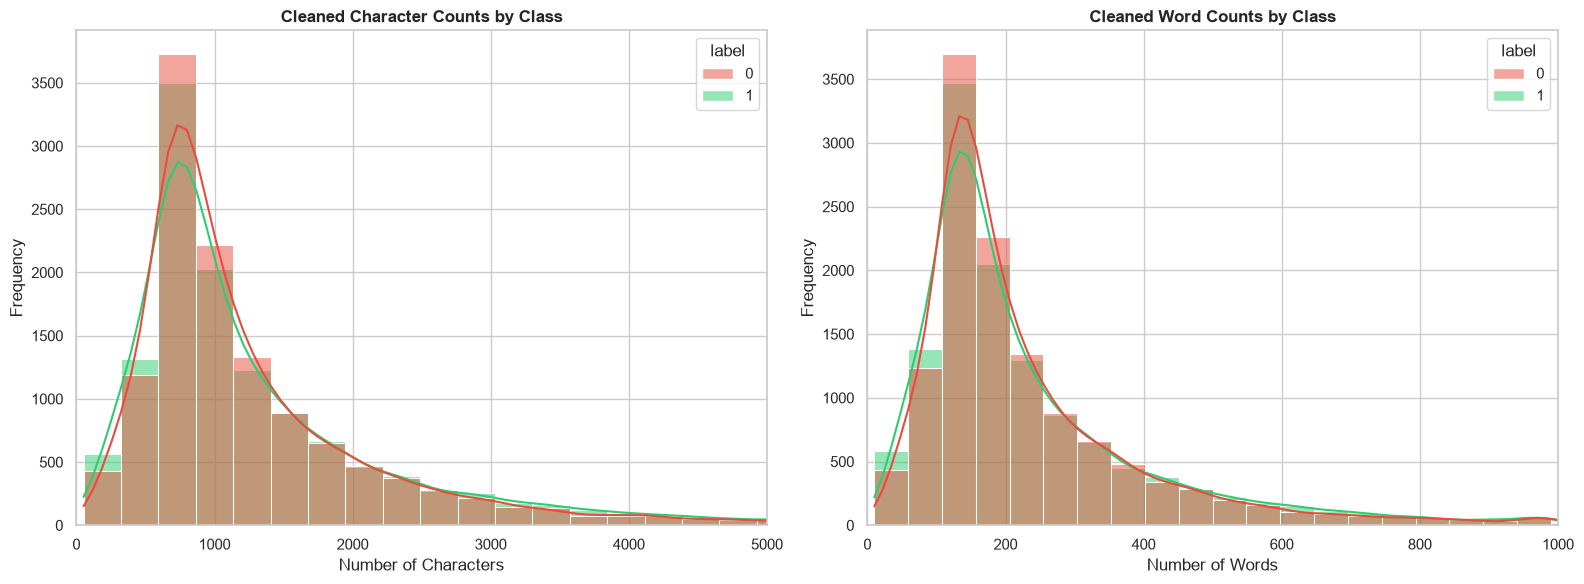


=== Clean Word Count Statistics ===


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,12500.0,228.48728,164.871918,10.0,127.0,173.0,276.0,1491.0
1,12500.0,234.48600,178.782103,12.0,124.0,172.0,288.0,2459.0


In [24]:
# Calculate lengths on CLEAN text
df['char_count'] = df['text_clean'].apply(len)
df['word_count'] = df['text_clean'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Character Count Distribution
sns.histplot(data=df, x='char_count', hue='label', bins=50, kde=True, ax=axes[0], palette=['#e74c3c', '#2ecc71'])
axes[0].set_title('Cleaned Character Counts by Class', fontweight='bold')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 5000)

# Word Count Distribution
sns.histplot(data=df, x='word_count', hue='label', bins=50, kde=True, ax=axes[1], palette=['#e74c3c', '#2ecc71'])
axes[1].set_title('Cleaned Word Counts by Class', fontweight='bold')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(0, 1000)

plt.tight_layout()
plt.show()

print("\n=== Clean Word Count Statistics ===")
display(df.groupby('label')['word_count'].describe())

---
## 8. WordClouds (Cleaned Text)
Visualizing the most prominent words in positive vs. negative reviews without HTML garbage.

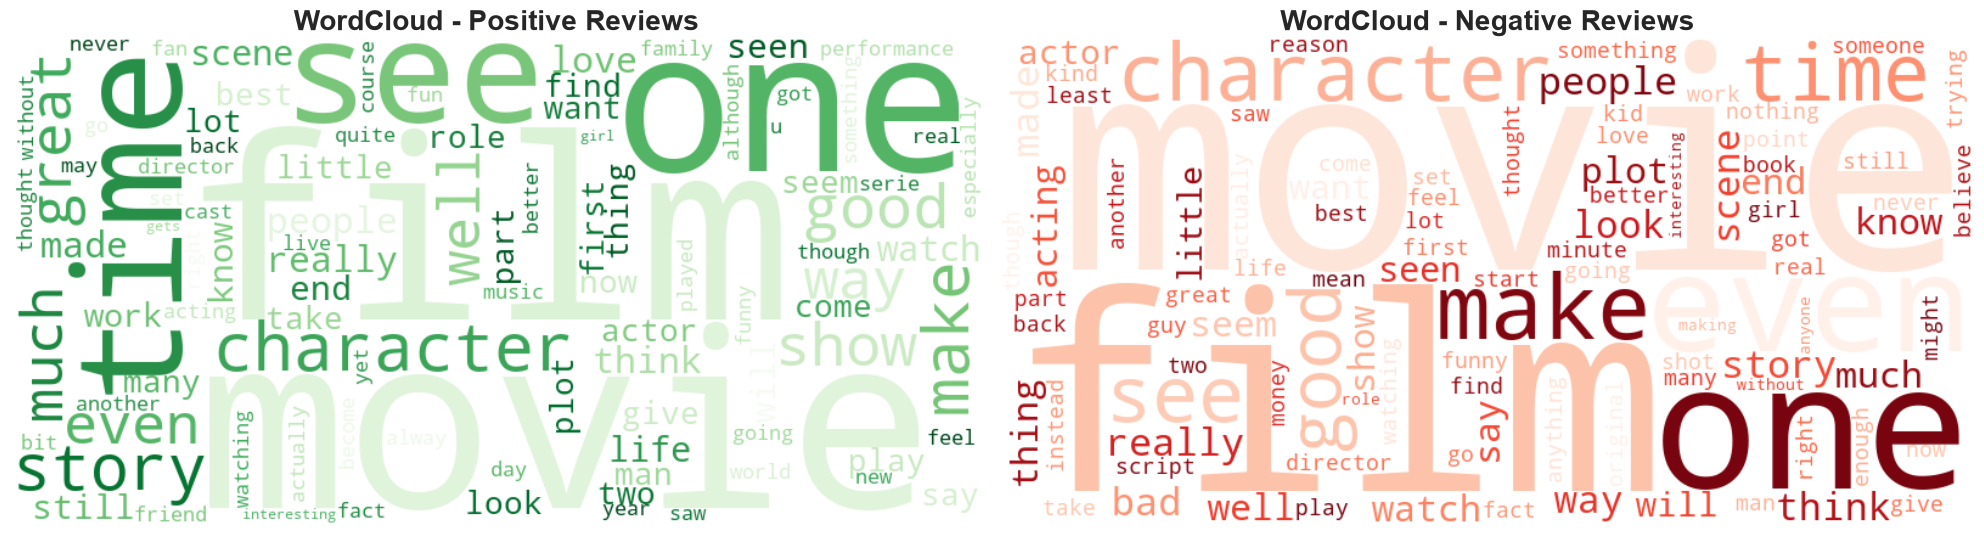

In [25]:
pos_text = " ".join(df[df['label'] == 1]['text_clean'])
neg_text = " ".join(df[df['label'] == 0]['text_clean'])

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Positive WordCloud
wc_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens', max_words=100).generate(pos_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('WordCloud - Positive Reviews', fontsize=20, fontweight='bold')

# Negative WordCloud
wc_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=100).generate(neg_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('WordCloud - Negative Reviews', fontsize=20, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 9. N-Gram Analysis (Cleaned Text)
Checking which single words (unigrams) and pairs of words (bigrams) appear most frequently now that the HTML is gone.

C:\Users\dhanu\AppData\Local\Temp\ipykernel_600580\3005972901.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=uni_df, x='Frequency', y='Word', ax=axes[0], palette='Blues_r')
C:\Users\dhanu\AppData\Local\Temp\ipykernel_600580\3005972901.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bi_df, x='Frequency', y='Bigram', ax=axes[1], palette='Purples_r')


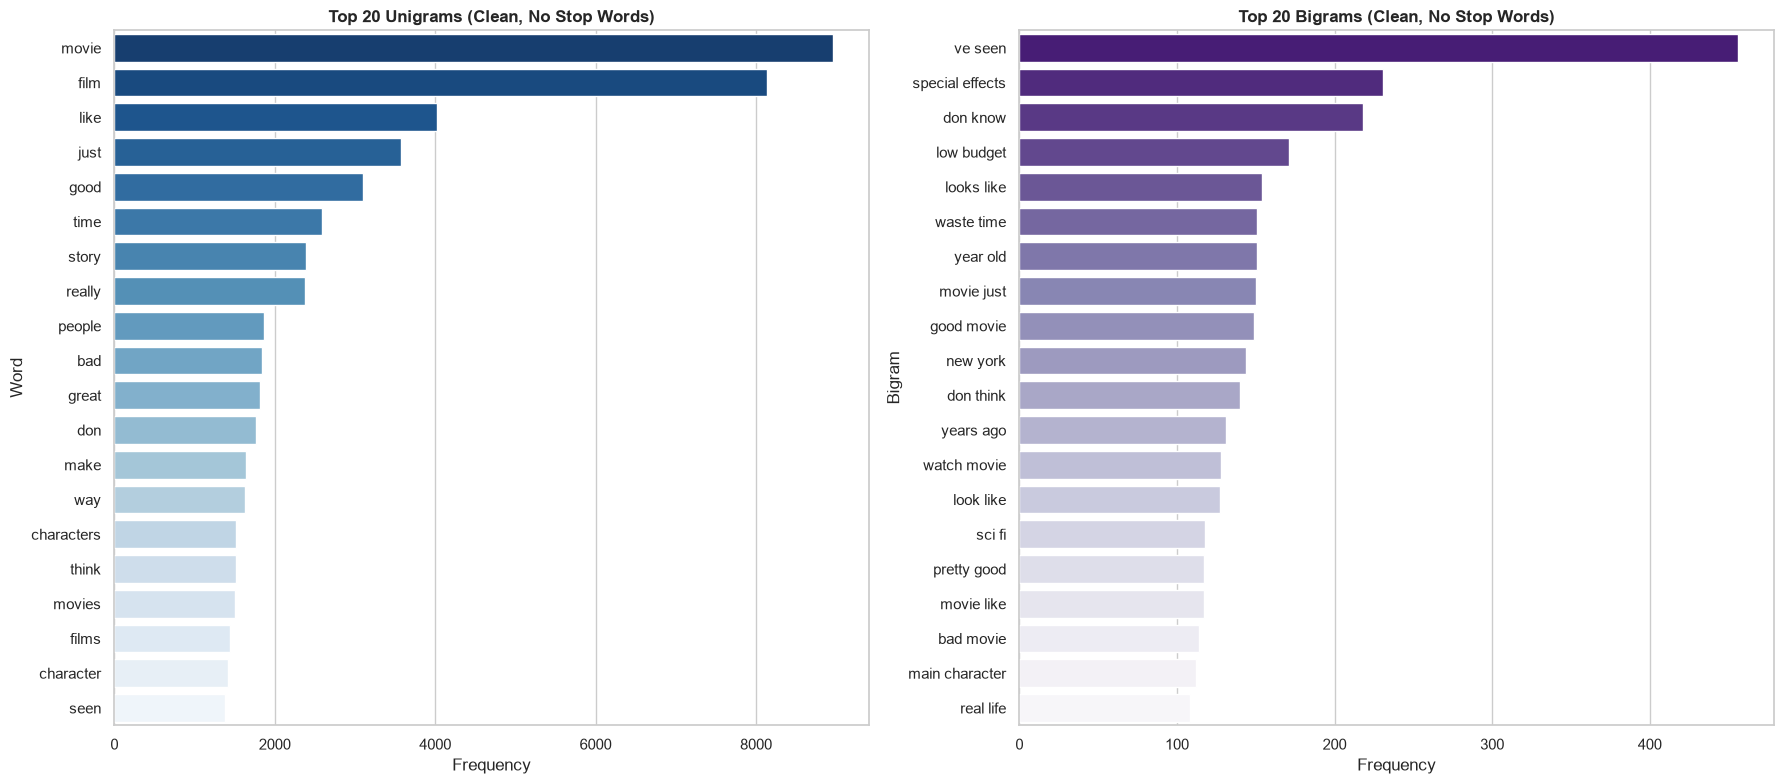

In [26]:
def get_top_ngrams(corpus, n=1, top_k=20):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# Sample 5000 rows to speed up n-gram processing
sample_df = df.sample(5000, random_state=42)

top_unigrams = get_top_ngrams(sample_df['text_clean'], n=1)
top_bigrams  = get_top_ngrams(sample_df['text_clean'], n=2)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Unigrams Plot
uni_df = pd.DataFrame(top_unigrams, columns=['Word', 'Frequency'])
sns.barplot(data=uni_df, x='Frequency', y='Word', ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 20 Unigrams (Clean, No Stop Words)', fontweight='bold')

# Bigrams Plot
bi_df = pd.DataFrame(top_bigrams, columns=['Bigram', 'Frequency'])
sns.barplot(data=bi_df, x='Frequency', y='Bigram', ax=axes[1], palette='Purples_r')
axes[1].set_title('Top 20 Bigrams (Clean, No Stop Words)', fontweight='bold')

plt.tight_layout()
plt.show()

---
##  EDA Conclusions

1. **Balance**: The dataset is perfectly balanced (50% positive, 50% negative).
2. **Nulls/Duplicates**: There are no missing values, but a small fraction of reviews are exact duplicates (which will be dropped in the modeling pipeline).
3. **Lengths**: Positive and negative reviews have very similar text lengths, averaging around 125-135 words per review.
4. **Artifacts**: Over 50% of the raw data contained HTML `<br>` tags, proving that a data cleaning step is strictly necessary before model training.
5. **Vocabulary**: Once cleaned, the word clouds and N-grams show that standard movie review terminology ("good", "movie", "film", "bad") heavily dominates the corpus, confirming that standard NLP techniques (like BERT and LSTM) will be highly effective for sentiment analysis.